# End-to-end feedback-GRAPE quantum memory

This notebook tests whether feedback-GRAPE can protect an **unknown qubit state** by encoding it in the cavity, applying repeated measurement-conditioned feedback, and decoding it back into the qubit.

For every stochastic trajectory:

1. sample a Haar-random qubit state
   $$
   |\psi\rangle=\alpha|0\rangle+\beta|1\rangle,
   \qquad |\alpha|^2+|\beta|^2=1,
   $$
   and initialize the cavity in vacuum;
2. apply a trainable joint qubit--cavity **encoding pulse**;
3. apply the same recurrent feedback-GRAPE step as in the state-stabilization notebook for $N$ rounds;
4. apply a trainable joint qubit--cavity **decoding pulse**;
5. maximize the fidelity between the retrieved qubit state and the original input state.

The encoder, recurrent controller, and decoder are common to all input states. The input amplitudes $\alpha$ and $\beta$ are never supplied to the controller. Both the encoder and decoder use the same 80-coefficient quadratic B-spline parameterization and the same pulse duration as one feedback correction pulse.


## Imports and reproducibility


In [16]:
import json
from datetime import datetime
from pathlib import Path
from zoneinfo import ZoneInfo

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import jax
import jax.numpy as jnp
import jax.scipy as jsp

import optax
import flax.linen as nn
from flax.training.train_state import TrainState

from toolbox import *

print("jax", jax.__version__)
print("jaxlib", jax.lib.__version__)
print("devices", jax.devices())

seed = 1234
key = jax.random.key(seed)


jax 0.6.2
jaxlib 0.6.2
devices [CudaDevice(id=0)]


## Experimental parameters


In [17]:
def _strip_comment_keys(obj):
    # Recursively drop configuration keys that start with '//'.
    if isinstance(obj, dict):
        return {
            k: _strip_comment_keys(v)
            for k, v in obj.items()
            if not (isinstance(k, str) and k.startswith("//"))
        }
    if isinstance(obj, list):
        return [_strip_comment_keys(x) for x in obj]
    return obj


def load_config_dict(config_directory: Path, filename: str = "configuration.json") -> dict:
    path = (config_directory / filename).resolve()
    with path.open("r", encoding="utf-8") as f:
        return _strip_comment_keys(json.load(f))


config_directory = Path("")
cfg = load_config_dict(config_directory)

# Frequencies are angular frequencies in rad/us; numerically, MHz = 1/us.
chi = -2 * jnp.pi * cfg["chi_kHz"] * 1e-3
K_cg = 2 * jnp.pi * cfg["self_Kerr_kHz"] * 1e-3
K_ce = 2 * jnp.pi * cfg["self_Kerr_if_qubit_in_e_kHz"] * 1e-3

t1_qub = cfg["qubit_T1_us"]
t2_qub = cfg["qubit_T2_us"]
t1_cav = cfg["storage_T1_us"]

print("chi / 2pi (MHz):", float(chi / (2 * jnp.pi)))
print("K_c,g / 2pi (MHz):", float(K_cg / (2 * jnp.pi)))
print("K_c,e / 2pi (MHz):", float(K_ce / (2 * jnp.pi)))
print("T1 qubit (us):", t1_qub)
print("T2 qubit (us):", t2_qub)
print("T1 cavity (us):", t1_cav)


chi / 2pi (MHz): -0.6597474879999999
K_c,g / 2pi (MHz): -0.0007143000000000001
K_c,e / 2pi (MHz): -0.00035699999999999995
T1 qubit (us): 45.6
T2 qubit (us): 36.4
T1 cavity (us): 231.9


## Control parameterization and trainable parameters

The recurrent policy is a GRU with 80 hidden features followed by two dense layers. It returns four sets of 20 B-spline coefficients for the qubit and cavity I/Q quadratures.

The complete trainable parameter tree is

$$
\theta=\{\theta_{\mathrm{RNN}},\,h_0,\,c_{\mathrm{enc}},\,c_{\mathrm{dec}}\},
$$

where $h_0\in\mathbb{R}^{80}$ is one shared trainable initial GRU carry and $c_{\mathrm{enc}},c_{\mathrm{dec}}\in\mathbb{R}^{4\times20}$. Every trajectory starts from the same $h_0$; it is not conditioned on the unknown input state or on a random key. The same optimizer updates all four components jointly.


In [18]:
num_bspln = 20
delta_ns = 64

# Protocol timing is defined here so it is also available to the loaded-run
# history plot immediately after checkpoint restoration.
k = 2
skip_left = k
skip_right = k
n_knots = num_bspln + skip_left + skip_right
n_intervals = n_knots - k
T_ns_hw = n_intervals * delta_ns
T_us_hw = T_ns_hw / 1000.0
L_ns = (k + 1) * delta_ns
t_drive = T_us_hw
t_idle = 10.0

assert L_ns % 4 == 0

inp_shape = (1,)
rec_features = 4 * num_bspln
dense_features = [2 * rec_features, 2 * rec_features]

init_lr = 8.0e-6
final_lr = 1.0e-6

# training_curriculum = [
#     {"num_feedback_steps": 3, "batch_size": 128, "gradient_accumulation_steps": 1, "num_batches": 5_000},
#     {"num_feedback_steps": 5, "batch_size": 70, "gradient_accumulation_steps": 2, "num_batches": 5_000},
#     {"num_feedback_steps": 6, "batch_size": 64, "gradient_accumulation_steps": 2, "num_batches": 5_000},
#     {"num_feedback_steps": 7, "batch_size": 50, "gradient_accumulation_steps": 3, "num_batches": 5_000},
#     {"num_feedback_steps": 8, "batch_size": 45, "gradient_accumulation_steps": 4, "num_batches": 5_000},
#     {"num_feedback_steps": 9, "batch_size": 40, "gradient_accumulation_steps": 5, "num_batches": 5_000},
#     {"num_feedback_steps": 10, "batch_size": 36, "gradient_accumulation_steps": 6, "num_batches": 5_000},
# ]


# training_curriculum = [
#     {"num_feedback_steps": 11, "batch_size": 34, "gradient_accumulation_steps": 6, "num_batches": 5_000},
#     {"num_feedback_steps": 12, "batch_size": 31, "gradient_accumulation_steps": 6, "num_batches": 5_000},
#     {"num_feedback_steps": 13, "batch_size": 29, "gradient_accumulation_steps": 6, "num_batches": 5_000},
#     {"num_feedback_steps": 14, "batch_size": 27, "gradient_accumulation_steps": 6, "num_batches": 5_000},
#     {"num_feedback_steps": 15, "batch_size": 25, "gradient_accumulation_steps": 7, "num_batches": 5_000},
#     {"num_feedback_steps": 16, "batch_size": 24, "gradient_accumulation_steps": 7, "num_batches": 5_000},
#     {"num_feedback_steps": 17, "batch_size": 22, "gradient_accumulation_steps": 7, "num_batches": 5_000},
#     {"num_feedback_steps": 18, "batch_size": 20, "gradient_accumulation_steps": 8, "num_batches": 5_000},
#     {"num_feedback_steps": 19, "batch_size": 19, "gradient_accumulation_steps": 8, "num_batches": 5_000},
#     {"num_feedback_steps": 20, "batch_size": 18, "gradient_accumulation_steps": 9, "num_batches": 5_000},
# ]

training_curriculum = [
    # Already completed; keep these so next_stage_index remains consistent.
    {"num_feedback_steps": 11, "batch_size": 102, "gradient_accumulation_steps": 2, "num_batches": 1000},
    {"num_feedback_steps": 13, "batch_size": 29, "gradient_accumulation_steps": 6, "num_batches": 1000},
    {"num_feedback_steps": 14, "batch_size": 27, "gradient_accumulation_steps": 6, "num_batches": 400},
    {"num_feedback_steps": 15, "batch_size": 25, "gradient_accumulation_steps": 7, "num_batches": 400},
    {"num_feedback_steps": 16, "batch_size": 24, "gradient_accumulation_steps": 7, "num_batches": 600},
    {"num_feedback_steps": 18, "batch_size": 21, "gradient_accumulation_steps": 8, "num_batches": 600},
    {"num_feedback_steps": 20, "batch_size": 19, "gradient_accumulation_steps": 9, "num_batches": 800},
]

# training_curriculum = [
#     {"num_feedback_steps": 11, "batch_size": 34, "gradient_accumulation_steps": 6, "num_batches": 1000},
#     {"num_feedback_steps": 13, "batch_size": 29, "gradient_accumulation_steps": 6, "num_batches": 1000},
#     {"num_feedback_steps": 16, "batch_size": 24, "gradient_accumulation_steps": 7, "num_batches": 1000},
#     {"num_feedback_steps": 20, "batch_size": 19, "gradient_accumulation_steps": 9, "num_batches": 1000},
#     {"num_feedback_steps": 25, "batch_size": 15, "gradient_accumulation_steps": 12, "num_batches": 1000},
#     {"num_feedback_steps": 31, "batch_size": 12, "gradient_accumulation_steps": 15, "num_batches": 1000},
#     {"num_feedback_steps": 38, "batch_size": 10, "gradient_accumulation_steps": 18, "num_batches": 1000},
#     {"num_feedback_steps": 48, "batch_size": 8, "gradient_accumulation_steps": 24, "num_batches": 1000},
#     {"num_feedback_steps": 62, "batch_size": 6, "gradient_accumulation_steps": 30, "num_batches": 1000},
#     {"num_feedback_steps": 95, "batch_size": 4, "gradient_accumulation_steps": 45, "num_batches": 1000},
# ]

total_training_batches = sum(stage["num_batches"] for stage in training_curriculum)

constant_steps = 100
decay_steps = total_training_batches - constant_steps
pulse_init_scale = 0.04
baseline_include_encoding_decoding_time = True

lr_schedule = optax.join_schedules(
    schedules=[
        optax.constant_schedule(init_lr),
        optax.linear_schedule(
            init_value=init_lr,
            end_value=final_lr,
            transition_steps=decay_steps,
        ),
        optax.constant_schedule(final_lr),
    ],
    boundaries=[constant_steps, constant_steps + decay_steps],
)

optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(learning_rate=lr_schedule),
)


class FeedbackPolicy(nn.Module):
    @nn.compact
    def __call__(self, carry, x):
        gru_cell = nn.GRUCell(features=rec_features)
        carry, x = gru_cell(carry, x)

        for n_features in dense_features:
            x = nn.Dense(n_features)(x)
            x = jax.nn.relu(x)

        x = nn.Dense(4 * num_bspln)(x)
        return carry, x.reshape(4, num_bspln)


def init_carry(key):
    return nn.GRUCell(features=rec_features).initialize_carry(key, inp_shape)


def create_train_state(key):
    key_model, key_enc, key_dec = jax.random.split(key, 3)
    model = FeedbackPolicy()

    fake_carry = init_carry(jax.random.key(0))
    fake_input = jnp.ones(inp_shape)
    controller_params = model.init(key_model, fake_carry, fake_input)["params"]

    params = {
        "controller": controller_params,
        # One shared trainable initial GRU state for every trajectory.
        "initial_carry": jnp.zeros_like(fake_carry),
        "encoding_coeffs": pulse_init_scale * jax.random.normal(
            key_enc, (4, num_bspln)
        ),
        "decoding_coeffs": pulse_init_scale * jax.random.normal(
            key_dec, (4, num_bspln)
        ),
    }

    return TrainState.create(
        apply_fn=model.apply,
        params=params,
        tx=optimizer,
    )


def apply_feedback_policy(train_state, params, carry, measurement):
    return train_state.apply_fn(
        {"params": params["controller"]}, carry, measurement
    )


key, subkey = jax.random.split(key)
train_state = create_train_state(subkey)

print("RNN output size:", rec_features)
print("dense layers:", dense_features)
print("encoder coefficients:", train_state.params["encoding_coeffs"].shape)
print("decoder coefficients:", train_state.params["decoding_coeffs"].shape)
print("trainable initial carry:", train_state.params["initial_carry"].shape)


RNN output size: 80
dense layers: [160, 160]
encoder coefficients: (4, 20)
decoder coefficients: (4, 20)
trainable initial carry: (80,)


## Load a trained model or resume a continuation run

Use `load_mode = "parameters_only"` for the first continuation from an existing parameter checkpoint. Every new checkpoint contains the shared trainable initial carry together with the controller, encoder, and decoder.

Legacy checkpoints are supported. If a parameter checkpoint has no `initial_carry`, the loader inserts an 80-component zero vector. If a legacy full-state checkpoint lacks the carry, the loader also inserts zero Adam moments for the new carry while preserving the trained moments, optimizer count, parameters, and PRNG key for all existing leaves.

After a restart, set `load_mode = "full_state"` and `resume_run_name` to the continuation folder. Leaving `resume_stage_checkpoint = None` automatically selects its newest completed stage.


In [19]:
import orbax.checkpoint as ocp

# First continuation from the old notebook:
#     load_mode = "parameters_only"
# Later, to resume a stage checkpoint including Adam and the PRNG key:
#     load_mode = "full_state"
load_mode = "parameters_only"

pretrained_run_name = "20260720_0935"
resume_run_name = None
resume_stage_checkpoint = None  # None selects the newest completed stage.
checkpoint_step = 1

load_root = Path("quantum_memory").resolve()
load_root.mkdir(parents=True, exist_ok=True)
checkpointer = ocp.Checkpointer(ocp.StandardCheckpointHandler())

start_stage_index = 0
global_step = 0


def without_initial_carry(params):
    legacy_params = dict(params)
    legacy_params.pop("initial_carry", None)
    return legacy_params


def with_zero_initial_carry(params):
    if "initial_carry" in params:
        return params
    params_with_carry = dict(params)
    params_with_carry["initial_carry"] = jnp.zeros_like(
        train_state.params["initial_carry"]
    )
    return params_with_carry


def add_zero_carry_moments(opt_state):
    """Add zero optimizer moments to legacy parameter-like subtrees."""
    if isinstance(opt_state, dict):
        updated = {
            key: add_zero_carry_moments(value)
            for key, value in opt_state.items()
        }
        parameter_keys = {
            "controller",
            "encoding_coeffs",
            "decoding_coeffs",
        }
        if parameter_keys.issubset(opt_state) and "initial_carry" not in opt_state:
            updated["initial_carry"] = jnp.zeros_like(
                train_state.params["initial_carry"]
            )
        return updated
    if isinstance(opt_state, tuple) and hasattr(opt_state, "_fields"):
        return type(opt_state)(
            *(add_zero_carry_moments(value) for value in opt_state)
        )
    if isinstance(opt_state, tuple):
        return tuple(add_zero_carry_moments(value) for value in opt_state)
    if isinstance(opt_state, list):
        return [add_zero_carry_moments(value) for value in opt_state]
    return opt_state


def restore_parameters_with_optional_carry(checkpoint_path):
    try:
        restored_params = checkpointer.restore(
            checkpoint_path,
            args=ocp.args.StandardRestore(train_state.params),
        )
        if "initial_carry" in restored_params:
            return restored_params, False
        return with_zero_initial_carry(restored_params), True
    except Exception as carry_restore_error:
        legacy_target = without_initial_carry(train_state.params)
        try:
            legacy_params = checkpointer.restore(
                checkpoint_path,
                args=ocp.args.StandardRestore(legacy_target),
            )
        except Exception:
            raise carry_restore_error
        return with_zero_initial_carry(legacy_params), True


if load_mode == "parameters_only":
    loaded_run_folder = load_root / pretrained_run_name
    pretrained_checkpoint_path = (
        loaded_run_folder
        / "params_only"
        / str(checkpoint_step)
    )
    if not pretrained_checkpoint_path.exists():
        raise FileNotFoundError(
            f"Parameter checkpoint does not exist: {pretrained_checkpoint_path}"
        )

    restored_params, inserted_zero_carry = (
        restore_parameters_with_optional_carry(pretrained_checkpoint_path)
    )
    train_state = train_state.replace(
        step=0,
        params=restored_params,
        opt_state=train_state.tx.init(restored_params),
    )

    timestamp = datetime.now(ZoneInfo("Europe/Paris")).strftime(
        "%Y%m%d_%H%M%S"
    )
    run_folder = load_root / timestamp
    run_folder.mkdir(parents=True, exist_ok=False)

    print("Loaded parameters from:", pretrained_checkpoint_path)
    if inserted_zero_carry:
        print("Legacy checkpoint: initialized the missing trainable carry to zero.")
    print(
        "The parameter-only checkpoint has no optimizer state; "
        "Adam is initialized once at the continuation learning rate."
    )
    print("Continuation results will be saved to:", run_folder)

elif load_mode == "full_state":
    if resume_run_name is None:
        raise ValueError(
            "Set resume_run_name to the continuation run to resume."
        )

    run_folder = load_root / resume_run_name
    loaded_run_folder = run_folder
    full_state_root = run_folder / "full_state_by_stage"
    if not full_state_root.exists():
        raise FileNotFoundError(
            f"Full-state directory does not exist: {full_state_root}"
        )

    if resume_stage_checkpoint is None:
        candidates = sorted(
            path for path in full_state_root.iterdir() if path.is_dir()
        )
        if not candidates:
            raise FileNotFoundError(
                f"No completed-stage checkpoint found in {full_state_root}"
            )
        full_checkpoint_path = candidates[-1]
    else:
        full_checkpoint_path = full_state_root / resume_stage_checkpoint

    restore_target = {
        "train_state_step": train_state.step,
        "params": train_state.params,
        "opt_state": train_state.opt_state,
        "key": key,
        "next_stage_index": jnp.asarray(0),
        "global_step": jnp.asarray(0),
    }

    inserted_zero_carry = False
    try:
        restored = checkpointer.restore(
            full_checkpoint_path,
            args=ocp.args.StandardRestore(restore_target),
        )
    except Exception as carry_restore_error:
        legacy_params_target = without_initial_carry(train_state.params)
        legacy_restore_target = {
            **restore_target,
            "params": legacy_params_target,
            "opt_state": train_state.tx.init(legacy_params_target),
        }
        try:
            restored = checkpointer.restore(
                full_checkpoint_path,
                args=ocp.args.StandardRestore(legacy_restore_target),
            )
        except Exception:
            raise carry_restore_error
        restored["params"] = with_zero_initial_carry(restored["params"])
        restored["opt_state"] = add_zero_carry_moments(
            restored["opt_state"]
        )
        inserted_zero_carry = True

    # Some Orbax versions tolerate a missing target leaf instead of raising.
    # Enforce the carry invariant explicitly in that case as well.
    if "initial_carry" not in restored["params"]:
        restored["params"] = with_zero_initial_carry(restored["params"])
        restored["opt_state"] = add_zero_carry_moments(
            restored["opt_state"]
        )
        inserted_zero_carry = True

    train_state = train_state.replace(
        step=restored["train_state_step"],
        params=restored["params"],
        opt_state=restored["opt_state"],
    )
    key = restored["key"]
    start_stage_index = int(restored["next_stage_index"])
    global_step = int(restored["global_step"])

    print("Restored full training state from:", full_checkpoint_path)
    if inserted_zero_carry:
        print(
            "Legacy full-state checkpoint: inserted a zero carry and zero "
            "Adam moments for it; existing optimizer moments were preserved."
        )
    print("Next stage index:", start_stage_index)
    print("Global optimizer update:", global_step)

else:
    raise ValueError(
        "load_mode must be 'parameters_only' or 'full_state'."
    )


Loaded parameters from: /home/user/python_experiments/train_feedback_grape/quantum_memory/20260720_0935/params_only/1
Legacy checkpoint: initialized the missing trainable carry to zero.
The parameter-only checkpoint has no optimizer state; Adam is initialized once at the continuation learning rate.
Continuation results will be saved to: /home/user/python_experiments/train_feedback_grape/quantum_memory/20260721_111149


Loaded training history from: /home/user/python_experiments/train_feedback_grape/quantum_memory/20260720_0935/memory_training_results.npz


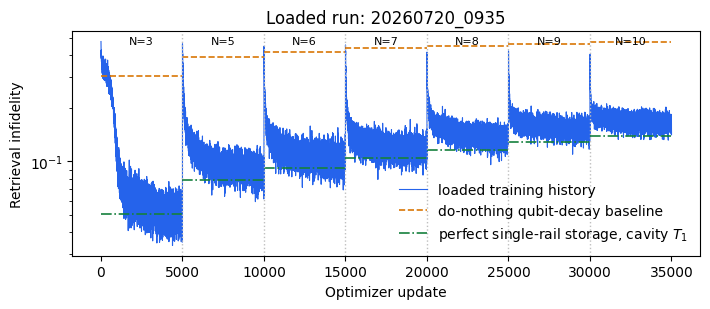

In [20]:
# Plot the training history stored with the loaded model.
loaded_history_candidates = [
    loaded_run_folder / "training_history.npz",
    loaded_run_folder / "memory_training_results.npz",
]
loaded_history_path = next(
    (path for path in loaded_history_candidates if path.exists()),
    None,
)

if loaded_history_path is None:
    print("No saved training history was found for:", loaded_run_folder)
else:
    with np.load(loaded_history_path, allow_pickle=False) as loaded_history:
        loaded_fidelity = np.asarray(
            loaded_history["mean_retrieval_fidelity_train"],
            dtype=float,
        )
        loaded_boundaries = (
            np.asarray(loaded_history["stage_boundaries"], dtype=int)
            if "stage_boundaries" in loaded_history.files
            else np.asarray([0, len(loaded_fidelity)], dtype=int)
        )

        if "stage_feedback_steps" in loaded_history.files:
            loaded_stage_feedback_steps = np.asarray(
                loaded_history["stage_feedback_steps"], dtype=int
            )
        elif "training_feedback_steps" in loaded_history.files:
            per_update_steps = np.asarray(
                loaded_history["training_feedback_steps"], dtype=int
            )
            loaded_stage_feedback_steps = np.asarray(
                [per_update_steps[start] for start in loaded_boundaries[:-1]],
                dtype=int,
            )
        else:
            loaded_stage_feedback_steps = None

        if "baseline_feedback_steps" in loaded_history.files:
            loaded_baseline_steps = np.asarray(
                loaded_history["baseline_feedback_steps"], dtype=int
            )
            loaded_baseline_fidelities = np.asarray(
                loaded_history["baseline_fidelities"], dtype=float
            )
        elif (
            "training_feedback_steps" in loaded_history.files
            and "training_do_nothing_fidelities" in loaded_history.files
        ):
            per_update_steps = np.asarray(
                loaded_history["training_feedback_steps"], dtype=int
            )
            per_update_baselines = np.asarray(
                loaded_history["training_do_nothing_fidelities"],
                dtype=float,
            )
            loaded_baseline_steps = loaded_stage_feedback_steps
            loaded_baseline_fidelities = np.asarray(
                [
                    per_update_baselines[start]
                    for start in loaded_boundaries[:-1]
                ],
                dtype=float,
            )
        else:
            loaded_baseline_steps = None
            loaded_baseline_fidelities = None

    loaded_steps = np.arange(1, len(loaded_fidelity) + 1)
    loaded_infidelity = 1.0 - loaded_fidelity
    positive = np.isfinite(loaded_infidelity) & (loaded_infidelity > 0.0)

    fig, ax = plt.subplots(figsize=(7.2, 3.2))
    ax.plot(
        loaded_steps[positive],
        loaded_infidelity[positive],
        color="#2563eb",
        lw=0.8,
        label="loaded training history",
    )

    if (
        loaded_stage_feedback_steps is not None
        and len(loaded_stage_feedback_steps) == len(loaded_boundaries) - 1
    ):
        loaded_baseline_by_steps = (
            {
                int(feedback_steps): float(fidelity)
                for feedback_steps, fidelity in zip(
                    loaded_baseline_steps,
                    loaded_baseline_fidelities,
                )
            }
            if loaded_baseline_steps is not None
            else {}
        )

        passive_storage_times = (
            2.0 * t_drive
            + loaded_stage_feedback_steps * (t_idle + t_drive)
        )
        passive_survival = np.exp(
            -passive_storage_times / float(t1_cav)
        )
        passive_cavity_fidelities = (
            3.0
            + 2.0 * np.sqrt(passive_survival)
            + passive_survival
        ) / 6.0

        for position, (feedback_steps, start, stop) in enumerate(
            zip(
                loaded_stage_feedback_steps,
                loaded_boundaries[:-1],
                loaded_boundaries[1:],
            )
        ):
            if int(feedback_steps) in loaded_baseline_by_steps:
                ax.hlines(
                    1.0 - loaded_baseline_by_steps[int(feedback_steps)],
                    start + 1,
                    stop,
                    color="#d97706",
                    ls="--",
                    lw=1.2,
                    label=(
                        "do-nothing qubit-decay baseline"
                        if position == 0
                        else None
                    ),
                )
            ax.hlines(
                1.0 - passive_cavity_fidelities[position],
                start + 1,
                stop,
                color="#15803d",
                ls="-.",
                lw=1.2,
                label=(
                    r"perfect single-rail storage, cavity $T_1$"
                    if position == 0
                    else None
                ),
            )
            ax.text(
                0.5 * (start + stop),
                0.98,
                f"N={feedback_steps}",
                transform=ax.get_xaxis_transform(),
                ha="center",
                va="top",
                fontsize=8,
            )

    for boundary in loaded_boundaries[1:-1]:
        ax.axvline(boundary, color="0.75", ls=":", lw=1.0)

    ax.set_xlabel("Optimizer update")
    ax.set_ylabel("Retrieval infidelity")
    ax.set_yscale("log")
    ax.set_title(f"Loaded run: {loaded_run_folder.name}")
    ax.legend(frameon=False)
    fig.tight_layout()

    if np.any(~positive):
        print(
            "Note: non-positive or non-finite infidelities were omitted "
            "from the logarithmic history plot."
        )
    print("Loaded training history from:", loaded_history_path)


# Physical model

The physical model below is the same as in the original cavity-state stabilization notebook.

During the feedback latency, the measured qubit has already been reset to $|0\rangle$, so the cavity evolves under its ground-state self-Kerr and photon loss. During every driven pulse, the joint qubit--cavity Hamiltonian contains the dispersive coupling and the qubit-state-dependent cavity Kerr. Qubit relaxation, qubit dephasing, and cavity relaxation are applied throughout the pulse.


## Idle evolution: cavity self-Kerr and photon loss


In [21]:
def liouv_relax_channel(c):
    # Lindblad dissipator in the row-major vectorization convention.
    d = c.shape[0]
    I = identity(d)
    cdag_c = hconj(c) @ c

    L = tensor(c, c.conj())
    L -= 0.5 * tensor(cdag_c, I)
    L -= 0.5 * tensor(I, cdag_c.T)
    return L


def liouv_hamiltonian(H):
    # Hamiltonian Liouvillian -i[H,rho] in row-major vectorization.
    d = H.shape[0]
    I = identity(d)
    return -1j * (tensor(H, I) - tensor(I, H.T))


def make_cavity_idle_matrix(N_cav, t1_cav, t_idle):
    a = destroy(N_cav)
    adag = hconj(a)

    H_kerr_cav = 0.5 * K_cg * adag @ adag @ a @ a
    c_loss = a / jnp.sqrt(t1_cav)

    L_idle = liouv_hamiltonian(H_kerr_cav)
    L_idle += liouv_relax_channel(c_loss)
    return jsp.linalg.expm(L_idle * t_idle)


def make_idle_cav(N_cav, t1_qub, t2_qub, t1_cav, t_idle):
    # t1_qub and t2_qub are intentionally unused here: the qubit has been reset.
    idle_cav_matrix = make_cavity_idle_matrix(N_cav, t1_cav, t_idle)
    ket_g = basis(2)
    rho_g = ket_g @ hconj(ket_g)

    def idle_cav(rho):
        rho_cav = rho[:N_cav, :N_cav]
        rho_cav = (idle_cav_matrix @ rho_cav.reshape(-1, 1)).reshape(
            N_cav, N_cav
        )

        rho_out = tensor(rho_g, rho_cav)
        return rho_out / jnp.trace(rho_out)

    return idle_cav


## Driven joint qubit--cavity evolution with relaxation


In [22]:
mu_qub = 20.0
mu_cav = 20.0


def build_drive_htree(N_cav, chi, e_qub, e_cav):
    a = tensor(identity(2), destroy(N_cav))
    adag = hconj(a)
    n_phot = adag @ a

    sigz = tensor(sigma.z, identity(N_cav))
    sigp = tensor(sigma.p, identity(N_cav))
    one = tensor(identity(2), identity(N_cav))

    H_disp = (chi / 2) * n_phot @ (one - sigz)

    proj_g = 0.5 * (one + sigz)
    proj_e = 0.5 * (one - sigz)
    kerr_op = adag @ adag @ a @ a
    H_kerr = 0.5 * (K_cg * proj_g + K_ce * proj_e) @ kerr_op

    H_drift = H_disp + H_kerr

    return [
        [H_drift, 1, 1, 0],
        [mu_qub * sigp, e_qub, 1, 1],
        [mu_cav * adag, 1j * jnp.conj(e_cav), 1, 1],
    ]


def get_uevol_matrix(N_cav, chi, e_qub, e_cav, dt):
    htree = build_drive_htree(N_cav, chi, e_qub, e_cav)
    return evol_hdt_exp(hmat_from_htree(htree), dt)


def liouv_relax_channel_qubit_cav(c):
    L = tensor(c, c.conj())
    L -= 0.5 * tensor(hconj(c) @ c, identity(len(c)))
    L -= 0.5 * tensor(identity(len(c)), (hconj(c) @ c).T)
    return L


def eval_idling_matrix(c_ops, t):
    L = sum(liouv_relax_channel_qubit_cav(c) for c in c_ops)
    return jsp.linalg.expm(L * t)


def build_c_ops(N_cav, t1_qub, t2_qub, t1_cav):
    t_phi_qub = 1 / ((1 / t2_qub) - (1 / t1_qub) / 2)

    sigm = tensor(sigma.m, identity(N_cav))
    sigz = tensor(sigma.z, identity(N_cav))
    a = tensor(identity(2), destroy(N_cav))

    return [
        sigm / jnp.sqrt(t1_qub),
        sigz / jnp.sqrt(2 * t_phi_qub),
        a / jnp.sqrt(t1_cav),
    ]


def make_idle_dt(N_cav, t1_qub, t2_qub, t1_cav, t):
    idling_matrix = eval_idling_matrix(
        build_c_ops(N_cav, t1_qub, t2_qub, t1_cav), t
    )

    def idle_dt(rho):
        rho_vec = idling_matrix @ rho.reshape(-1, 1)
        return rho_vec.reshape(rho.shape)

    return idle_dt


def make_drive_with_relax(N_cav, chi, t1_qub, t2_qub, t1_cav, dt_idle):
    idle_after_drive_dt = make_idle_dt(
        N_cav, t1_qub, t2_qub, t1_cav, dt_idle
    )

    def drive_with_relax(rho_init, es_qub, es_cav, dts):
        def one_interval(rho, fields_and_dt):
            e_qub, e_cav, dt = fields_and_dt
            U = get_uevol_matrix(N_cav, chi, e_qub, e_cav, dt)[0]
            rho = U @ rho @ hconj(U)
            rho = idle_after_drive_dt(rho)
            return rho, None

        rho_final, _ = jax.lax.scan(
            one_interval, rho_init, [es_qub, es_cav, dts]
        )
        return rho_final

    return drive_with_relax


def ctrl_from_coeffs(ctrl_coeffs, bsplines):
    controls = ctrl_coeffs @ bsplines
    e_qub = controls[0] + 1j * controls[1]
    e_cav = controls[2] + 1j * controls[3]
    return e_qub, e_cav


## Projective readout, cavity backaction, and qubit reset

For the sampled outcome $y\in\{0,1\}$, the corresponding diagonal qubit block is selected with its Born probability. The cavity coherences then acquire the same Gaussian phase-noise channel as in the original notebook,

$$
(\rho_c)_{mn}\longrightarrow
\exp\!\left[-\frac{\sigma_y^2}{2}(m-n)^2\right](\rho_c)_{mn},
$$

after which the qubit is reset to $|0\rangle$. The binary controller input is $m_k=+1$ for outcome $0$ and $m_k=-1$ for outcome $1$.


In [23]:
def measure_sz(key, rho_init):
    probs = rho_init.diagonal().reshape(2, -1).sum(axis=1).real
    outcome_index = jax.random.choice(key, 2, p=probs)
    prob = probs[outcome_index]

    rho_cav = jnp.where(
        outcome_index == 0,
        rho_init[: rho_init.shape[0] // 2, : rho_init.shape[1] // 2],
        rho_init[rho_init.shape[0] // 2 :, rho_init.shape[1] // 2 :],
    )

    ket_g = basis(2)
    rho_out = tensor(ket_g @ hconj(ket_g), rho_cav)
    rho_out /= jnp.trace(rho_out)

    measurement = 1 - 2 * outcome_index
    return measurement, prob, rho_out


## Numerical dimensions, timing, and quadratic B-spline basis


In [24]:
ndt_drive = 150
N_cav = 22

t_drive_edges = jnp.linspace(0.0, t_drive, ndt_drive + 1)
t_drive_mids = 0.5 * (t_drive_edges[1:] + t_drive_edges[:-1])
t_drive_intvs = t_drive_edges[1:] - t_drive_edges[:-1]

bspline_builder = setup_bspline_builder(
    0.0,
    t_drive_edges[-1],
    n_knots,
    k,
    skip_left,
    skip_right,
)
bsplns_mids = bspline_builder(t_drive_mids)
bsplns_edges = bspline_builder(t_drive_edges)

print("B-spline degree:", k)
print("number of coefficients per quadrature:", num_bspln)
print("single B-spline support:", L_ns, "ns")
print("encoding/correction/decoding pulse duration:", T_ns_hw, "ns")
print("maximum simultaneous B-splines:", k + 1)


B-spline degree: 2
number of coefficients per quadrature: 20
single B-spline support: 192 ns
encoding/correction/decoding pulse duration: 1408 ns
maximum simultaneous B-splines: 3


# End-to-end quantum-memory trajectory

The initial state is

$$
\rho_0(\psi)=|\psi\rangle\!\langle\psi|\otimes|0\rangle_c\!\langle0|.
$$

The trainable encoding pulse is applied first. Each feedback step then performs, in order:

1. projective qubit measurement, effective cavity backaction, and qubit reset;
2. cavity evolution during the feedback latency;
3. GRU update from the binary measurement outcome;
4. measurement-conditioned joint qubit--cavity correction pulse.

After $N$ steps, the trainable decoding pulse is applied directly to the final joint state. No measurement or reset is inserted between the final correction and decoding. The output cavity is traced out and the terminal reward is

$$
F_{\mathrm{ret}}(\psi,\mathbf m)
=\langle\psi|\rho_{q,\mathrm{out}}|\psi\rangle.
$$


In [25]:
def sample_haar_qubit(key):
    # Sample a pure qubit uniformly from the Bloch sphere.
    key_z, key_phi = jax.random.split(key)
    z = jax.random.uniform(key_z, minval=-1.0, maxval=1.0)
    phi = 2 * jnp.pi * jax.random.uniform(key_phi)

    alpha = jnp.sqrt((1.0 + z) / 2.0)
    beta = jnp.exp(1j * phi) * jnp.sqrt((1.0 - z) / 2.0)
    psi = alpha * basis(2, 0) + beta * basis(2, 1)

    bloch = jnp.array(
        [
            2 * jnp.real(jnp.conj(alpha) * beta),
            2 * jnp.imag(jnp.conj(alpha) * beta),
            jnp.abs(alpha) ** 2 - jnp.abs(beta) ** 2,
        ]
    )
    return psi, bloch


def reduced_qubit_state(rho_joint, N_cav):
    rho_tensor = rho_joint.reshape(2, N_cav, 2, N_cav)
    return jnp.trace(rho_tensor, axis1=1, axis2=3)


def qubit_state_fidelity(rho_qubit, psi_target):
    return jnp.real((hconj(psi_target) @ rho_qubit @ psi_target)[0, 0])


def qubit_bloch_vector(rho_qubit):
    return jnp.array(
        [
            2 * jnp.real(rho_qubit[0, 1]),
            -2 * jnp.imag(rho_qubit[0, 1]),
            jnp.real(rho_qubit[0, 0] - rho_qubit[1, 1]),
        ]
    )


def do_nothing_qubit_decay_fidelity(
    num_feedback_steps,
    include_encoding_decoding_time=True,
):
    # Exact Haar-average fidelity if the state is left in the decaying qubit.
    total_wait_time = num_feedback_steps * (t_idle + t_drive)
    if include_encoding_decoding_time:
        total_wait_time += 2 * t_drive

    t_phi_qub = 1 / ((1 / t2_qub) - (1 / t1_qub) / 2)
    qubit_liouvillian = liouv_relax_channel(
        sigma.m / jnp.sqrt(t1_qub)
    )
    qubit_liouvillian += liouv_relax_channel(
        sigma.z / jnp.sqrt(2 * t_phi_qub)
    )
    qubit_decay_channel = jsp.linalg.expm(
        qubit_liouvillian * total_wait_time
    )

    ket_0 = basis(2, 0)
    ket_1 = basis(2, 1)
    cardinal_states = [
        ket_0,
        ket_1,
        (ket_0 + ket_1) / jnp.sqrt(2),
        (ket_0 - ket_1) / jnp.sqrt(2),
        (ket_0 + 1j * ket_1) / jnp.sqrt(2),
        (ket_0 - 1j * ket_1) / jnp.sqrt(2),
    ]

    fidelities = []
    for psi_input in cardinal_states:
        rho_input = psi_input @ hconj(psi_input)
        rho_output = (
            qubit_decay_channel @ rho_input.reshape(-1, 1)
        ).reshape(2, 2)
        fidelities.append(
            qubit_state_fidelity(rho_output, psi_input)
        )

    # The six Pauli eigenstates form a qubit state 2-design, so their mean
    # is the exact Haar-average fidelity for this linear channel.
    return jnp.mean(jnp.asarray(fidelities)), total_wait_time


## One recurrent feedback step


In [26]:
def make_feedback_step(N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle):
    idle_cav = make_idle_cav(N_cav, t1_qub, t2_qub, t1_cav, t_idle)
    drive = make_drive_with_relax(
        N_cav,
        chi,
        t1_qub,
        t2_qub,
        t1_cav,
        t_drive_intvs[0],
    )

    def feedback_step(key, rho, train_state, params, carry):
        measurement, prob, rho = measure_sz(
            key,
            rho,
        )

        rho = idle_cav(rho)

        rnn_input = jnp.array([measurement], dtype=float)
        carry, ctrl_coeffs = apply_feedback_policy(
            train_state, params, carry, rnn_input
        )

        e_qub, e_cav = ctrl_from_coeffs(ctrl_coeffs, bsplns_mids)
        rho = drive(rho, e_qub, e_cav, t_drive_intvs)
        return rho, carry, measurement, prob

    return feedback_step


## Encoding, repeated feedback, decoding, and terminal fidelity


In [27]:
def make_quantum_memory_trajectories(
    N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle
):
    feedback_step = make_feedback_step(
        N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle
    )
    drive = make_drive_with_relax(
        N_cav,
        chi,
        t1_qub,
        t2_qub,
        t1_cav,
        t_drive_intvs[0],
    )

    def trajectory_from_state(
        key,
        train_state,
        params,
        num_feedback_steps,
        psi_input,
    ):
        # Preserve the previous key splitting convention for trajectory
        # reproducibility, but use one shared trainable initial carry.
        _, key_scan = jax.random.split(key)
        carry = params["initial_carry"]

        psi_initial = tensor(psi_input, basis(N_cav, 0))
        rho = psi_initial @ hconj(psi_initial)

        e_qub, e_cav = ctrl_from_coeffs(
            params["encoding_coeffs"], bsplns_mids
        )
        rho = drive(rho, e_qub, e_cav, t_drive_intvs)

        def one_feedback_step(scan_carry, _):
            key_step, rho_step, carry_step = scan_carry
            key_step, subkey = jax.random.split(key_step)

            rho_step, carry_step, measurement, prob = feedback_step(
                subkey,
                rho_step,
                train_state,
                params,
                carry_step,
            )
            return (key_step, rho_step, carry_step), (measurement, prob)

        (_, rho, carry), (measurements, probs) = jax.lax.scan(
            one_feedback_step,
            (key_scan, rho, carry),
            length=num_feedback_steps,
        )

        e_qub, e_cav = ctrl_from_coeffs(
            params["decoding_coeffs"], bsplns_mids
        )
        rho = drive(rho, e_qub, e_cav, t_drive_intvs)

        rho_qubit_out = reduced_qubit_state(rho, N_cav)
        retrieval_fidelity = qubit_state_fidelity(
            rho_qubit_out, psi_input
        )

        return retrieval_fidelity, measurements, probs, rho_qubit_out

    def random_trajectory(
        key, train_state, params, num_feedback_steps
    ):
        key_input, key_dynamics = jax.random.split(key)
        psi_input, input_bloch = sample_haar_qubit(key_input)

        retrieval_fidelity, measurements, probs, rho_qubit_out = (
            trajectory_from_state(
                key_dynamics,
                train_state,
                params,
                num_feedback_steps,
                psi_input,
            )
        )
        return (
            retrieval_fidelity,
            measurements,
            probs,
            input_bloch,
            rho_qubit_out,
        )

    return random_trajectory, trajectory_from_state


# Feedback-GRAPE gradient

Let $\mathbf m=(m_1,\ldots,m_N)$ denote the sampled measurement record and let $P_\theta(\mathbf m|\psi)$ be its probability under the current encoder and feedback policy. The optimized objective is the average retrieval fidelity

$$
J(\theta)=
\mathbb E_{\psi\sim\mathrm{Haar}}
\mathbb E_{\mathbf m\sim P_\theta(\cdot|\psi)}
\left[F_{\mathrm{ret}}(\psi,\mathbf m)\right].
$$

The same feedback-GRAPE estimator as in the original notebook is used:

$$
\nabla_\theta J
=\mathbb E_{\psi,\mathbf m}
\left[
\nabla_\theta F_{\mathrm{ret}}
+F_{\mathrm{ret}}\nabla_\theta\log P_\theta(\mathbf m|\psi)
\right].
$$

For a fixed sampled record, automatic differentiation supplies the direct derivative through the encoder, simulated dynamics, recurrent controller, and decoder. The score-function term accounts for the dependence of the discrete measurement-record probabilities on the trainable parameters. The Haar distribution of input states is independent of $\theta$, so it requires no score term.

The code implements this gradient with the surrogate

$$
F_{\mathrm{ret}}+
\operatorname{stopgrad}(F_{\mathrm{ret}})
\sum_{k=1}^{N}\log p_\theta(m_k|m_{<k},\psi).
$$


In [28]:
def make_trajectory_with_rewgrad(
    N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle
):
    random_trajectory, _ = make_quantum_memory_trajectories(
        N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle
    )

    def trajectory_with_rewgrad(key, train_state, num_feedback_steps):
        def objective_for_one_sample(params):
            trajectory_output = random_trajectory(
                key,
                train_state,
                params,
                num_feedback_steps,
            )
            retrieval_fidelity, _, probs, _, _ = trajectory_output

            reward = jnp.clip(jnp.real(retrieval_fidelity), 0.0, 1.0)
            safe_probs = jnp.clip(probs, 1e-8, 1.0)
            log_record_probability = jnp.log(safe_probs).sum()

            feedback_grape_surrogate = (
                reward
                + jax.lax.stop_gradient(reward)
                * log_record_probability
            )
            return feedback_grape_surrogate, reward

        gradient_function = jax.grad(
            objective_for_one_sample, has_aux=True
        )
        reward_gradient, retrieval_fidelity = gradient_function(
            train_state.params
        )
        return reward_gradient, retrieval_fidelity

    return trajectory_with_rewgrad


## Vectorized training and testing batches


In [29]:
def make_train_on_batch(
    N_cav,
    chi,
    t1_qub,
    t2_qub,
    t1_cav,
    t_idle,
    batch_size,
    num_feedback_steps,
    gradient_accumulation_steps,
):
    trajectory_with_rewgrad = make_trajectory_with_rewgrad(
        N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle
    )
    batched_trajectory_with_rewgrad = jax.vmap(
        trajectory_with_rewgrad, in_axes=(0, None, None)
    )

    @jax.jit
    def train_on_batch(key, train_state):
        microbatch_keys = jax.random.split(
            key, gradient_accumulation_steps
        )
        zero_reward_gradient = jax.tree.map(
            jnp.zeros_like, train_state.params
        )

        def accumulate_one_microbatch(reward_gradient_sum, microbatch_key):
            trajectory_keys = jax.random.split(
                microbatch_key, batch_size
            )

            reward_gradients, retrieval_fidelities = (
                batched_trajectory_with_rewgrad(
                    trajectory_keys,
                    train_state,
                    num_feedback_steps,
                )
            )

            mean_reward_gradient = jax.tree.map(
                lambda x: x.mean(axis=0), reward_gradients
            )
            reward_gradient_sum = jax.tree.map(
                lambda accumulated, current: accumulated + current,
                reward_gradient_sum,
                mean_reward_gradient,
            )
            microbatch_mean_fidelity = jnp.mean(retrieval_fidelities)
            return reward_gradient_sum, microbatch_mean_fidelity

        reward_gradient_sum, microbatch_mean_fidelities = jax.lax.scan(
            accumulate_one_microbatch,
            zero_reward_gradient,
            microbatch_keys,
        )

        mean_reward_gradient = jax.tree.map(
            lambda x: x / gradient_accumulation_steps,
            reward_gradient_sum,
        )

        loss_gradient = jax.tree.map(
            lambda x: -x, mean_reward_gradient
        )
        raw_gradient_norm = optax.global_norm(loss_gradient)
        train_state = train_state.apply_gradients(
            grads=loss_gradient
        )
        return (
            train_state,
            microbatch_mean_fidelities,
            raw_gradient_norm,
        )

    return train_on_batch


def make_test_on_batch(
    N_cav,
    chi,
    t1_qub,
    t2_qub,
    t1_cav,
    t_idle,
    batch_size,
    num_feedback_steps,
):
    random_trajectory, _ = make_quantum_memory_trajectories(
        N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle
    )
    batched_random_trajectory = jax.vmap(
        random_trajectory, in_axes=(0, None, None, None)
    )

    @jax.jit
    def test_on_batch(key, train_state):
        keys = jax.random.split(key, batch_size)
        return batched_random_trajectory(
            keys,
            train_state,
            train_state.params,
            num_feedback_steps,
        )

    return test_on_batch


# Continue training the end-to-end memory

The continuation curriculum increases the number of feedback rounds progressively from $N=10$ to $N=20$. The encoder, recurrent controller, decoder, and Adam state are carried continuously between stages. Smaller microbatches control peak GPU memory, while independently sampled microbatch gradients are averaged before each optimizer update.

The persistent history is deliberately compact. Retrieval fidelity, raw pre-clipping gradient norm, and learning rate are stored once per optimizer update. Stage boundaries and batch settings are stored once per completed stage. The exact do-nothing fidelity and duration are calculated and stored once per distinct value of $N$.

During training, each stage prints its static configuration and baseline once. A single updating progress line then shows the current fidelity, raw gradient norm, and learning rate. After every completed stage, the notebook saves the compact history, a parameter-only checkpoint, and a full checkpoint containing the parameters, Adam moments, optimizer step, PRNG key, and next curriculum stage.


In [ ]:
history_path = run_folder / "training_history.npz"

if load_mode == "full_state" and history_path.exists():
    with np.load(history_path, allow_pickle=False) as saved_history:
        # The full-state checkpoint is the completed-stage marker. Truncate
        # per-update histories to it if a later write was interrupted.
        mean_retrieval_fidelity_train = saved_history[
            "mean_retrieval_fidelity_train"
        ][:global_step].tolist()
        training_learning_rates = saved_history[
            "training_learning_rates"
        ][:global_step].tolist()

        if "training_gradient_norms" in saved_history.files:
            training_gradient_norms = saved_history[
                "training_gradient_norms"
            ][:global_step].tolist()
        else:
            # Compatibility with a checkpoint made before gradient norms
            # were recorded.
            training_gradient_norms = [
                float("nan")
            ] * len(mean_retrieval_fidelity_train)

        stage_boundaries = [
            int(boundary)
            for boundary in saved_history["stage_boundaries"]
            if int(boundary) <= global_step
        ]
        num_completed_stages = max(0, len(stage_boundaries) - 1)

        if "stage_feedback_steps" in saved_history.files:
            # Compact history schema.
            stage_feedback_steps = saved_history[
                "stage_feedback_steps"
            ][:num_completed_stages].astype(int).tolist()
            stage_batch_sizes = saved_history[
                "stage_batch_sizes"
            ][:num_completed_stages].astype(int).tolist()
            stage_accumulation_steps = saved_history[
                "stage_accumulation_steps"
            ][:num_completed_stages].astype(int).tolist()
            stage_effective_batch_sizes = saved_history[
                "stage_effective_batch_sizes"
            ][:num_completed_stages].astype(int).tolist()
        else:
            # Convert the original redundant per-update arrays once.
            stage_starts = stage_boundaries[:-1]
            stage_feedback_steps = [
                int(saved_history["training_feedback_steps"][start])
                for start in stage_starts
            ]
            stage_batch_sizes = [
                int(saved_history["training_batch_sizes"][start])
                for start in stage_starts
            ]
            stage_accumulation_steps = [
                int(saved_history["training_accumulation_steps"][start])
                for start in stage_starts
            ]
            stage_effective_batch_sizes = [
                int(saved_history[
                    "training_effective_batch_sizes"
                ][start])
                for start in stage_starts
            ]

        if "baseline_feedback_steps" in saved_history.files:
            baseline_feedback_steps = saved_history[
                "baseline_feedback_steps"
            ].astype(int).tolist()
            baseline_fidelities = saved_history[
                "baseline_fidelities"
            ].astype(float).tolist()
            baseline_wait_times = saved_history[
                "baseline_wait_times"
            ].astype(float).tolist()
        else:
            # Convert the original per-update baseline values into one value
            # per distinct N.
            baseline_feedback_steps = []
            baseline_fidelities = []
            baseline_wait_times = []
            legacy_baselines = saved_history[
                "training_do_nothing_fidelities"
            ]
            for stage_start, feedback_steps in zip(
                stage_boundaries[:-1], stage_feedback_steps
            ):
                if feedback_steps in baseline_feedback_steps:
                    continue
                baseline_feedback_steps.append(feedback_steps)
                baseline_fidelities.append(
                    float(legacy_baselines[stage_start])
                )
                wait_time = feedback_steps * (t_idle + t_drive)
                if baseline_include_encoding_decoding_time:
                    wait_time += 2.0 * t_drive
                baseline_wait_times.append(float(wait_time))
else:
    mean_retrieval_fidelity_train = []
    training_gradient_norms = []
    training_learning_rates = []

    stage_boundaries = [global_step]
    stage_feedback_steps = []
    stage_batch_sizes = []
    stage_accumulation_steps = []
    stage_effective_batch_sizes = []

    baseline_feedback_steps = []
    baseline_fidelities = []
    baseline_wait_times = []


def save_current_history():
    np.savez(
        history_path,
        history_schema_version=np.asarray(2),
        mean_retrieval_fidelity_train=np.asarray(
            mean_retrieval_fidelity_train
        ),
        training_gradient_norms=np.asarray(training_gradient_norms),
        training_learning_rates=np.asarray(training_learning_rates),
        stage_boundaries=np.asarray(stage_boundaries),
        stage_feedback_steps=np.asarray(stage_feedback_steps),
        stage_batch_sizes=np.asarray(stage_batch_sizes),
        stage_accumulation_steps=np.asarray(
            stage_accumulation_steps
        ),
        stage_effective_batch_sizes=np.asarray(
            stage_effective_batch_sizes
        ),
        baseline_feedback_steps=np.asarray(baseline_feedback_steps),
        baseline_fidelities=np.asarray(baseline_fidelities),
        baseline_wait_times=np.asarray(baseline_wait_times),
    )


baseline_cache = {
    int(feedback_steps): (float(fidelity), float(wait_time))
    for feedback_steps, fidelity, wait_time in zip(
        baseline_feedback_steps,
        baseline_fidelities,
        baseline_wait_times,
    )
}


for stage_index in range(start_stage_index, len(training_curriculum)):
    stage = training_curriculum[stage_index]
    num_feedback_steps_train = stage["num_feedback_steps"]
    batch_size = stage["batch_size"]
    gradient_accumulation_steps = stage["gradient_accumulation_steps"]
    effective_batch_size = batch_size * gradient_accumulation_steps
    num_stage_batches = stage["num_batches"]

    if num_feedback_steps_train not in baseline_cache:
        do_nothing_fidelity, baseline_wait_time = (
            do_nothing_qubit_decay_fidelity(
                num_feedback_steps_train,
                include_encoding_decoding_time=(
                    baseline_include_encoding_decoding_time
                ),
            )
        )
        baseline_cache[num_feedback_steps_train] = (
            float(do_nothing_fidelity),
            float(baseline_wait_time),
        )
        baseline_feedback_steps.append(num_feedback_steps_train)
        baseline_fidelities.append(float(do_nothing_fidelity))
        baseline_wait_times.append(float(baseline_wait_time))

    do_nothing_fidelity, baseline_wait_time = baseline_cache[
        num_feedback_steps_train
    ]

    print(
        f"\nStage {stage_index + 1}/{len(training_curriculum)}: "
        f"N={num_feedback_steps_train}, microbatch={batch_size}, "
        f"accumulation={gradient_accumulation_steps}, "
        f"effective batch={effective_batch_size}, "
        f"updates={num_stage_batches}"
    )
    print(
        "Do-nothing qubit-decay baseline: "
        f"F_avg={do_nothing_fidelity:.8f} after "
        f"{baseline_wait_time:.3f} us"
    )

    train_on_batch = make_train_on_batch(
        N_cav,
        chi,
        t1_qub,
        t2_qub,
        t1_cav,
        t_idle,
        batch_size,
        num_feedback_steps_train,
        gradient_accumulation_steps,
    )

    progress = tqdm(
        range(num_stage_batches),
        desc=f"N={num_feedback_steps_train}",
        dynamic_ncols=True,
        leave=True,
    )
    for stage_step in progress:
        key, subkey = jax.random.split(key)
        (
            train_state,
            microbatch_mean_fidelities,
            raw_gradient_norm,
        ) = train_on_batch(subkey, train_state)

        mean_fidelity = float(jnp.mean(microbatch_mean_fidelities))
        raw_gradient_norm = float(raw_gradient_norm)
        learning_rate = float(lr_schedule(global_step))

        mean_retrieval_fidelity_train.append(mean_fidelity)
        training_gradient_norms.append(raw_gradient_norm)
        training_learning_rates.append(learning_rate)

        progress.set_postfix(
            fidelity=f"{mean_fidelity:.7f}",
            grad_norm=f"{raw_gradient_norm:.3e}",
            lr=f"{learning_rate:.2e}",
            refresh=True,
        )
        global_step += 1

    stage_boundaries.append(global_step)
    stage_feedback_steps.append(num_feedback_steps_train)
    stage_batch_sizes.append(batch_size)
    stage_accumulation_steps.append(gradient_accumulation_steps)
    stage_effective_batch_sizes.append(effective_batch_size)
    next_stage_index = stage_index + 1

    full_state_payload = {
        "train_state_step": train_state.step,
        "params": train_state.params,
        "opt_state": train_state.opt_state,
        "key": key,
        "next_stage_index": jnp.asarray(next_stage_index),
        "global_step": jnp.asarray(global_step),
    }

    stage_name = (
        f"stage_{stage_index + 1:02d}_"
        f"N_{num_feedback_steps_train:02d}_"
        f"step_{global_step:06d}"
    )
    full_checkpoint_path = (
        run_folder / "full_state_by_stage" / stage_name
    )
    params_checkpoint_path = (
        run_folder / "params_by_stage" / stage_name
    )
    full_checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    params_checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

    # The full-state checkpoint is written last and therefore marks a
    # completely persisted stage.
    save_current_history()
    checkpointer.save(
        params_checkpoint_path,
        args=ocp.args.StandardSave(train_state.params),
    )
    checkpointer.save(
        full_checkpoint_path,
        args=ocp.args.StandardSave(full_state_payload),
    )

    print("Saved stage parameters to:", params_checkpoint_path)
    print("Saved complete stage state to:", full_checkpoint_path)

    # Rerunning this cell in the same kernel skips completed stages.
    start_stage_index = next_stage_index



Stage 1/7: N=11, microbatch=102, accumulation=2, effective batch=204, updates=1000
Do-nothing qubit-decay baseline: F_avg=0.52022445 after 128.304 us


N=11:   0%|          | 0/1000 [00:00<?, ?it/s]2026-07-21 11:11:51.702168: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-07-21 11:11:51.702201: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-07-21 11:11:51.702215: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-07-21 11:1

KeyboardInterrupt: 

: 

## Perfect passive single-rail retrieval fidelity

As a reference, assume that the unknown qubit is encoded perfectly into the first two Fock states of the storage cavity,

$$
\alpha |0\rangle_{\mathrm q}+\beta |1\rangle_{\mathrm q}
\longrightarrow
|g\rangle_{\mathrm q}
\otimes
\left(
\alpha |0\rangle_{\mathrm c}+\beta |1\rangle_{\mathrm c}
\right),
$$

and decoded perfectly after the full protocol duration. No measurement-based stabilization is applied; the encoded state experiences only cavity photon loss.

For $N$ feedback-time intervals, the storage duration is

$$
t_N
=
2t_{\mathrm{drive}}
+
N\left(t_{\mathrm{idle}}+t_{\mathrm{drive}}\right),
$$

with

$$
t_{\mathrm{drive}}=1.408~\mu\mathrm{s},
\qquad
t_{\mathrm{idle}}=10~\mu\mathrm{s},
\qquad
T_{1,\mathrm{cav}}=231.9~\mu\mathrm{s}.
$$

The single-photon survival probability is

$$
\eta_N=\exp\left(-\frac{t_N}{T_{1,\mathrm{cav}}}\right).
$$

Photon loss acts as an amplitude-damping channel on the logical
$\{|0\rangle_{\mathrm c},|1\rangle_{\mathrm c}\}$ subspace. Its exact
Bloch-sphere-averaged retrieval fidelity is

$$
F_{\mathrm{single\ rail}}(N)
=
\frac{3+2\sqrt{\eta_N}+\eta_N}{6}.
$$

| Feedback steps $N$ | Storage time $t_N$ ($\mu\mathrm{s}$) | Photon survival $\eta_N$ | Average retrieval fidelity |
|---:|---:|---:|---:|
| 10 | 116.896 | 0.604061 | 0.859748 |
| 11 | 128.304 | 0.575065 | 0.848621 |
| 12 | 139.712 | 0.547460 | 0.837878 |
| 13 | 151.120 | 0.521180 | 0.827506 |
| 14 | 162.528 | 0.496161 | 0.817489 |
| 15 | 173.936 | 0.472344 | 0.807815 |
| 16 | 185.344 | 0.449670 | 0.798470 |
| 17 | 196.752 | 0.428085 | 0.789441 |
| 18 | 208.160 | 0.407535 | 0.780717 |
| 19 | 219.568 | 0.387972 | 0.772287 |
| 20 | 230.976 | 0.369348 | 0.764138 |

This reference assumes perfect encoding and decoding. It therefore isolates
the fidelity limitation caused solely by the finite lifetime of the storage
cavity.

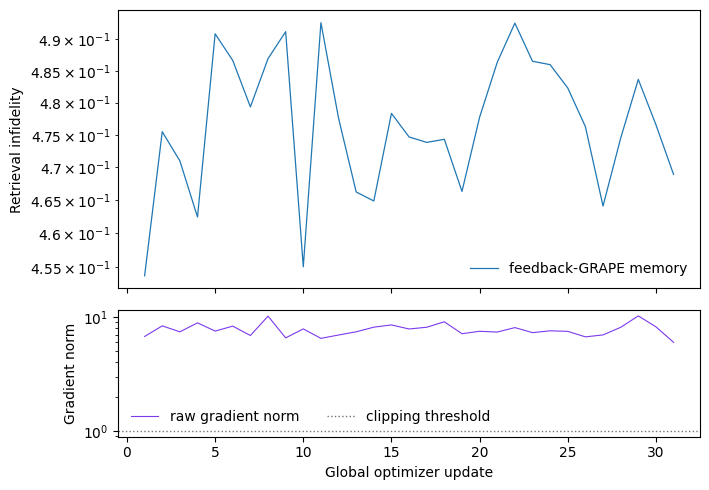

In [ ]:
training_fidelity = np.asarray(mean_retrieval_fidelity_train)
training_gradient_norms_array = np.asarray(training_gradient_norms)
training_steps = np.arange(1, len(training_fidelity) + 1)

stage_boundaries_array = np.asarray(stage_boundaries, dtype=int)
stage_feedback_steps_array = np.asarray(stage_feedback_steps, dtype=int)
stage_batch_sizes_array = np.asarray(stage_batch_sizes, dtype=int)

baseline_by_feedback_steps = {
    int(feedback_steps): float(fidelity)
    for feedback_steps, fidelity in zip(
        baseline_feedback_steps,
        baseline_fidelities,
    )
}

single_rail_storage_times = (
    2.0 * t_drive
    + stage_feedback_steps_array * (t_idle + t_drive)
)
single_rail_survival = np.exp(
    -single_rail_storage_times / float(t1_cav)
)
single_rail_fidelities = (
    3.0
    + 2.0 * np.sqrt(single_rail_survival)
    + single_rail_survival
) / 6.0

fig, (ax, ax_grad) = plt.subplots(
    2,
    1,
    figsize=(7.2, 5.0),
    sharex=True,
    gridspec_kw={"height_ratios": [2.2, 1.0]},
)

ax.plot(
    training_steps,
    1.0 - training_fidelity,
    lw=0.9,
    label="feedback-GRAPE memory",
)

for stage_position, (start, stop, feedback_steps) in enumerate(
    zip(
        stage_boundaries_array[:-1],
        stage_boundaries_array[1:],
        stage_feedback_steps_array,
    )
):
    do_nothing_fidelity = baseline_by_feedback_steps[int(feedback_steps)]
    ax.hlines(
        1.0 - do_nothing_fidelity,
        start + 1,
        stop,
        color="#d97706",
        ls="--",
        lw=1.2,
        label=(
            "do-nothing qubit-decay baseline"
            if stage_position == 0
            else None
        ),
    )
    ax.hlines(
        1.0 - single_rail_fidelities[stage_position],
        start + 1,
        stop,
        color="#15803d",
        ls="-.",
        lw=1.2,
        label=(
            r"perfect single-rail storage, cavity $T_1$"
            if stage_position == 0
            else None
        ),
    )
    ax.text(
        0.5 * (start + stop),
        0.98,
        f"N={feedback_steps}, B={stage_batch_sizes_array[stage_position]}",
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="top",
        fontsize=8,
    )

valid_gradient = (
    np.isfinite(training_gradient_norms_array)
    & (training_gradient_norms_array > 0.0)
)
ax_grad.plot(
    training_steps[valid_gradient],
    training_gradient_norms_array[valid_gradient],
    color="#7c3aed",
    lw=0.8,
    label="raw gradient norm",
)
ax_grad.axhline(
    1.0,
    color="0.45",
    ls=":",
    lw=1.0,
    label="clipping threshold",
)

for boundary in stage_boundaries_array[1:-1]:
    ax.axvline(boundary, color="0.75", ls=":", lw=1.0)
    ax_grad.axvline(boundary, color="0.75", ls=":", lw=1.0)

ax.set_ylabel("Retrieval infidelity")
ax.set_yscale("log")
ax.legend(frameon=False)

ax_grad.set_xlabel("Global optimizer update")
ax_grad.set_ylabel("Gradient norm")
ax_grad.set_yscale("log")
ax_grad.legend(frameon=False, ncol=2)

fig.tight_layout()


# Held-out validation

For uniformly distributed unknown pure qubit states, any measure-and-prepare strategy is limited to an average fidelity of $2/3$. Exceeding this value on held-out Haar-random states is therefore the first meaningful indication that the learned channel preserves quantum information rather than only classical state information.


In [ ]:
num_feedback_steps_test = training_curriculum[-1]["num_feedback_steps"]
test_batch_size = 128

test_on_batch = make_test_on_batch(
    N_cav,
    chi,
    t1_qub,
    t2_qub,
    t1_cav,
    t_idle,
    test_batch_size,
    num_feedback_steps_test,
)

key, subkey = jax.random.split(key)
test_output = test_on_batch(subkey, train_state)

test_fidelities = np.asarray(test_output[0])
test_mean = test_fidelities.mean()
test_sem = test_fidelities.std(ddof=1) / np.sqrt(test_batch_size)

print(f"Held-out Haar-average retrieval fidelity: {test_mean:.5f} +/- {test_sem:.5f}")
print(f"Minimum held-out fidelity: {test_fidelities.min():.5f}")
print(f"Fraction above 2/3: {np.mean(test_fidelities > 2/3):.3f}")

fig, ax = plt.subplots(figsize=(5.0, 2.8))
ax.hist(test_fidelities, bins=20, color="#6f3db5", alpha=0.8)
ax.axvline(2 / 3, color="0.25", ls="--", label="classical bound")
ax.set_xlabel("Retrieval fidelity")
ax.set_ylabel("Held-out states")
ax.legend(frameon=False)
fig.tight_layout()


## Six cardinal input states

The six Pauli eigenstates test the poles of all three Bloch-sphere axes. Each reported value is averaged over independent stochastic measurement records while keeping the input state fixed.


In [ ]:


ket_0 = basis(2, 0)
ket_1 = basis(2, 1)

cardinal_states = [
    ket_0,
    ket_1,
    (ket_0 + ket_1) / jnp.sqrt(2),
    (ket_0 - ket_1) / jnp.sqrt(2),
    (ket_0 + 1j * ket_1) / jnp.sqrt(2),
    (ket_0 - 1j * ket_1) / jnp.sqrt(2),
]
cardinal_labels = ["+Z", "-Z", "+X", "-X", "+Y", "-Y"]
shots_per_cardinal_state = 64

_, trajectory_from_state = make_quantum_memory_trajectories(
    N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle
)


@jax.jit
def evaluate_one_fixed_state(keys, psi_input, train_state):
    return jax.vmap(
        lambda one_key: trajectory_from_state(
            one_key,
            train_state,
            train_state.params,
            num_feedback_steps_test,
            psi_input,
        )
    )(keys)


cardinal_fidelities = []
cardinal_output_bloch = []

for label, psi_input in zip(cardinal_labels, cardinal_states):
    key, subkey = jax.random.split(key)
    state_keys = jax.random.split(subkey, shots_per_cardinal_state)
    state_output = evaluate_one_fixed_state(
        state_keys, psi_input, train_state
    )

    mean_fidelity = float(jnp.mean(state_output[0]))
    mean_rho_qubit = jnp.mean(state_output[3], axis=0)

    cardinal_fidelities.append(mean_fidelity)
    cardinal_output_bloch.append(
        np.asarray(qubit_bloch_vector(mean_rho_qubit))
    )
    print(
        f"{label}: fidelity={mean_fidelity:.5f}, "
        f"output Bloch={cardinal_output_bloch[-1]}"
    )

fig, ax = plt.subplots(figsize=(5.2, 2.8))
ax.bar(cardinal_labels, cardinal_fidelities, color="#4b7fe8")
ax.axhline(2 / 3, color="0.25", ls="--", label="classical bound")
ax.set_ylim(0, 1)
ax.set_ylabel("Retrieval fidelity")
ax.legend(frameon=False)
fig.tight_layout()


# Validation checks before trusting the result

The following cells are deliberately separate from training. They test four possible sources of an artificially high fidelity:

1. loss of trace, Hermiticity, or positivity in the propagated density matrices;
2. encoder, decoder, or recurrent pulses leaving the intended amplitude range;
3. the learned encoder and decoder providing all of the improvement without any useful recurrent correction;
4. exploitation of the hard Fock-space boundary at `N_cav = 23`.

The feedback-off ablation retains the learned encoder and decoder, all projective readouts, readout backaction, resets, latency intervals, drift evolution, and pulse-duration slots. Only the measurement-conditioned correction amplitudes are set to zero. Its comparison with the complete protocol therefore isolates the contribution of the recurrent correction pulses.


In [ ]:
# Numerical physicality of the held-out output qubit states
rho_qubit_test = np.asarray(test_output[4])
rho_qubit_test_hermitian = 0.5 * (
    rho_qubit_test + np.swapaxes(rho_qubit_test.conj(), -1, -2)
)

trace_errors = np.abs(np.trace(rho_qubit_test, axis1=-2, axis2=-1) - 1.0)
hermiticity_errors = np.max(
    np.abs(rho_qubit_test - np.swapaxes(rho_qubit_test.conj(), -1, -2)),
    axis=(-2, -1),
)
minimum_eigenvalues = np.linalg.eigvalsh(rho_qubit_test_hermitian)[..., 0]

print("Maximum output-qubit trace error:", trace_errors.max())
print("Maximum output-qubit Hermiticity error:", hermiticity_errors.max())
print("Minimum output-qubit eigenvalue:", minimum_eigenvalues.min())
print("Maximum raw held-out fidelity:", test_fidelities.max())


def replay_feedback_coefficients(measurements, train_state):
    carry = init_carry(jax.random.key(0))

    def one_recurrent_step(carry, measurement):
        carry, coefficients = apply_feedback_policy(
            train_state,
            train_state.params,
            carry,
            jnp.asarray([measurement], dtype=float),
        )
        return carry, coefficients

    _, coefficients = jax.lax.scan(
        one_recurrent_step, carry, measurements
    )
    return coefficients


batched_replay_feedback_coefficients = jax.jit(
    jax.vmap(replay_feedback_coefficients, in_axes=(0, None))
)
feedback_coefficients_test = batched_replay_feedback_coefficients(
    test_output[1], train_state
)

encoding_fields = (
    train_state.params["encoding_coeffs"] @ bsplns_edges
)
decoding_fields = (
    train_state.params["decoding_coeffs"] @ bsplns_edges
)
feedback_fields = jnp.einsum(
    "btqn,ns->btqs",
    feedback_coefficients_test,
    bsplns_edges,
)


def print_field_summary(name, fields):
    fields = np.asarray(fields)
    qubit_envelope = np.sqrt(fields[..., 0, :] ** 2 + fields[..., 1, :] ** 2)
    cavity_envelope = np.sqrt(fields[..., 2, :] ** 2 + fields[..., 3, :] ** 2)
    print(
        f"{name}: max |qubit envelope|={qubit_envelope.max():.6f}, "
        f"max |cavity envelope|={cavity_envelope.max():.6f}, "
        f"max |quadrature|={np.abs(fields).max():.6f}"
    )


print_field_summary("Encoding", encoding_fields)
print_field_summary("Decoding", decoding_fields)
print_field_summary("Feedback", feedback_fields)


## Hilbert-space convergence: reevaluate at a larger cavity cutoff

The controller and all pulse coefficients are independent of `N_cav`, so the trained policy can be reevaluated without retraining at a larger cutoff. If `N_cav = 23` is sufficient, increasing the cutoff to 30 should leave the held-out fidelity unchanged within Monte-Carlo uncertainty. A significant drop indicates that the optimizer exploited the artificial boundary and the model must be retrained with a larger cavity space.


In [ ]:
N_cav_large = 30
truncation_microbatch_size = 16
truncation_num_microbatches = 4

test_at_training_cutoff = make_test_on_batch(
    N_cav,
    chi,
    t1_qub,
    t2_qub,
    t1_cav,
    t_idle,
    truncation_microbatch_size,
    num_feedback_steps_test,
)
test_at_large_cutoff = make_test_on_batch(
    N_cav_large,
    chi,
    t1_qub,
    t2_qub,
    t1_cav,
    t_idle,
    truncation_microbatch_size,
    num_feedback_steps_test,
)

fidelities_training_cutoff = []
fidelities_large_cutoff = []

for _ in range(truncation_num_microbatches):
    key, truncation_key = jax.random.split(key)
    output_training_cutoff = test_at_training_cutoff(
        truncation_key, train_state
    )
    output_large_cutoff = test_at_large_cutoff(
        truncation_key, train_state
    )

    fidelities_training_cutoff.append(
        np.asarray(output_training_cutoff[0])
    )
    fidelities_large_cutoff.append(
        np.asarray(output_large_cutoff[0])
    )

fidelities_training_cutoff = np.concatenate(
    fidelities_training_cutoff
)
fidelities_large_cutoff = np.concatenate(
    fidelities_large_cutoff
)
cutoff_differences = (
    fidelities_large_cutoff - fidelities_training_cutoff
)
cutoff_difference_sem = (
    cutoff_differences.std(ddof=1)
    / np.sqrt(len(cutoff_differences))
)

print(
    f"N_cav={N_cav}: mean fidelity="
    f"{fidelities_training_cutoff.mean():.6f}"
)
print(
    f"N_cav={N_cav_large}: mean fidelity="
    f"{fidelities_large_cutoff.mean():.6f}"
)
print(
    "Paired large-minus-training-cutoff difference: "
    f"{cutoff_differences.mean():+.6f} +/- "
    f"{cutoff_difference_sem:.6f}"
)


# Save the continuation results

Each completed stage has already been saved under `params_by_stage` and `full_state_by_stage`. This final cell writes an additional step-numbered parameter checkpoint together with the validation arrays, pulse coefficients, waveforms, and run metadata. It reuses the continuation `run_folder`; it does not create a second timestamped run.


In [ ]:
import orbax.checkpoint as ocp

final_checkpoint_path = (
    run_folder / "params_final" / f"step_{global_step:06d}"
)
final_checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

if not final_checkpoint_path.exists():
    checkpointer.save(
        final_checkpoint_path,
        args=ocp.args.StandardSave(train_state.params),
    )

params_host = jax.device_get(train_state.params)
encoding_coeffs = np.asarray(params_host["encoding_coeffs"])
decoding_coeffs = np.asarray(params_host["decoding_coeffs"])
initial_carry = np.asarray(params_host["initial_carry"])

np.savez(
    run_folder / "memory_training_results.npz",
    history_schema_version=np.asarray(2),
    mean_retrieval_fidelity_train=np.asarray(
        mean_retrieval_fidelity_train
    ),
    training_gradient_norms=np.asarray(training_gradient_norms),
    training_learning_rates=np.asarray(training_learning_rates),
    stage_boundaries=np.asarray(stage_boundaries),
    stage_feedback_steps=np.asarray(stage_feedback_steps),
    stage_batch_sizes=np.asarray(stage_batch_sizes),
    stage_accumulation_steps=np.asarray(stage_accumulation_steps),
    stage_effective_batch_sizes=np.asarray(
        stage_effective_batch_sizes
    ),
    baseline_feedback_steps=np.asarray(baseline_feedback_steps),
    baseline_fidelities=np.asarray(baseline_fidelities),
    baseline_wait_times=np.asarray(baseline_wait_times),
    held_out_retrieval_fidelities=test_fidelities,
    cardinal_fidelities=np.asarray(cardinal_fidelities),
    cardinal_output_bloch=np.asarray(cardinal_output_bloch),
    encoding_coeffs=encoding_coeffs,
    decoding_coeffs=decoding_coeffs,
    initial_carry=initial_carry,
    encoding_waveforms=encoding_coeffs @ np.asarray(bsplns_edges),
    decoding_waveforms=decoding_coeffs @ np.asarray(bsplns_edges),
)

metadata = {
    "seed": seed,
    "training_curriculum": training_curriculum,
    "total_training_batches": total_training_batches,
    "baseline_include_encoding_decoding_time": baseline_include_encoding_decoding_time,
    "history_schema_version": 2,
    "N_cav": N_cav,
    "pulse_duration_ns": int(T_ns_hw),
    "num_bsplines": num_bspln,
    "trainable_initial_carry": True,
    "initial_carry_norm": float(np.linalg.norm(initial_carry)),
    "held_out_mean_fidelity": float(test_mean),
    "held_out_sem": float(test_sem),
}
with (run_folder / "metadata.json").open("w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved to:", run_folder)
